<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/Day_4_Feature_Engineering_(Part_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SNAPSHOT = pd.Timestamp('2024-06-30')   # the day the data was pulled

cust = pd.read_csv('ecommerce_customers.csv',
                   parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
tx = pd.read_excel('transactions.xlsx', parse_dates=['order_date'])
print('customers:', cust.shape, '| transactions:', tx.shape)
tx.head()

customers: (2500, 15) | transactions: (8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


In [3]:
# -----------------------------------------------------------
# 🔹 1A. ROLL UP ORDER-LEVEL ROWS TO ONE ROW PER CUSTOMER
# -----------------------------------------------------------
rfm = tx.groupby('customer_id').agg(
    frequency=('amount', 'size'),                 # F: how many orders
    monetary=('amount', 'sum'),                   # M: total spent
    avg_order_value=('amount', 'mean'),           # typical basket
    last_order=('order_date', 'max'),
    n_categories=('category', 'nunique'),         # breadth of interest
).reset_index()
# R: recency = days since last order, measured from the snapshot
rfm['recency_days'] = (SNAPSHOT - rfm['last_order']).dt.days
rfm[['customer_id', 'frequency', 'monetary', 'avg_order_value',
     'recency_days', 'n_categories']].head()

,customer_id,frequency,monetary,avg_order_value,recency_days,n_categories
0,CUST00003,1,39.17,39.17,405,1
1,CUST00004,1,2.74,2.74,729,1
2,CUST00005,4,133.80,33.45,15,3
3,CUST00006,1,23.36,23.36,45,1
4,CUST00007,2,73.70,36.85,684,2


In [4]:
# -----------------------------------------------------------
# 🔹 1B. MERGE THE NEW FEATURES BACK ONTO THE CUSTOMER TABLE
# -----------------------------------------------------------
df = cust.merge(rfm.drop(columns='last_order'), on='customer_id', how='left')
# customers with no transactions -> fill sensible defaults
df['frequency'] = df['frequency'].fillna(0)
df['monetary'] = df['monetary'].fillna(0)
df['n_categories'] = df['n_categories'].fillna(0)
# never ordered -> recency is 'infinitely' stale: cap at customer tenure
df['recency_days'] = df['recency_days'].fillna(9999)
print('Merged shape:', df.shape)
df[['customer_id', 'frequency', 'monetary', 'recency_days', 'is_churned']].head()

Merged shape: (2500, 20)


,customer_id,frequency,monetary,recency_days,is_churned
0,CUST00001,0.0,0.00,9999.0,0
1,CUST00002,0.0,0.00,9999.0,1
2,CUST00003,1.0,39.17,405.0,0
3,CUST00004,1.0,2.74,729.0,0
4,CUST00005,4.0,133.80,15.0,0


In [6]:
# first & last order per customer -> active span in days
#    hint: tx.groupby('customer_id')['order_date'].agg(['min','max'])

active_span = tx.groupby('customer_id')['order_date'].agg(
    first_order='min',
    last_order='max'
).reset_index()
active_span['active_span_days'] = (active_span['last_order'] - active_span['first_order']).dt.days
display(active_span.head())

,customer_id,first_order,last_order,active_span_days
0,CUST00003,2023-05-22,2023-05-22,0
1,CUST00004,2022-07-02,2022-07-02,0
2,CUST00005,2022-09-18,2024-06-15,636
3,CUST00006,2024-05-16,2024-05-16,0
4,CUST00007,2021-10-04,2022-08-16,316


In [7]:
#avg_days_between_orders = span / (frequency - 1), guard freq<=1

df = df.merge(active_span[['customer_id', 'active_span_days']], on='customer_id', how='left')
# For customers with frequency <= 1, avg_days_between_orders is not applicable (NaN)
df['avg_days_between_orders'] = df.apply(lambda row: row['active_span_days'] / (row['frequency'] - 1) if row['frequency'] > 1 else np.nan, axis=1)
display(df[['customer_id', 'frequency', 'active_span_days', 'avg_days_between_orders']].head())

,customer_id,frequency,active_span_days,avg_days_between_orders
0,CUST00001,0.0,NaN,NaN
1,CUST00002,0.0,NaN,NaN
2,CUST00003,1.0,0.0,NaN
3,CUST00004,1.0,0.0,NaN
4,CUST00005,4.0,636.0,212.0


In [9]:
# merge onto df and show head

display(df[['customer_id', 'frequency', 'active_span_days', 'avg_days_between_orders']].head())

,customer_id,frequency,active_span_days,avg_days_between_orders
0,CUST00001,0.0,NaN,NaN
1,CUST00002,0.0,NaN,NaN
2,CUST00003,1.0,0.0,NaN
3,CUST00004,1.0,0.0,NaN
4,CUST00005,4.0,636.0,212.0


skew before: 1.73
skew after : -1.12


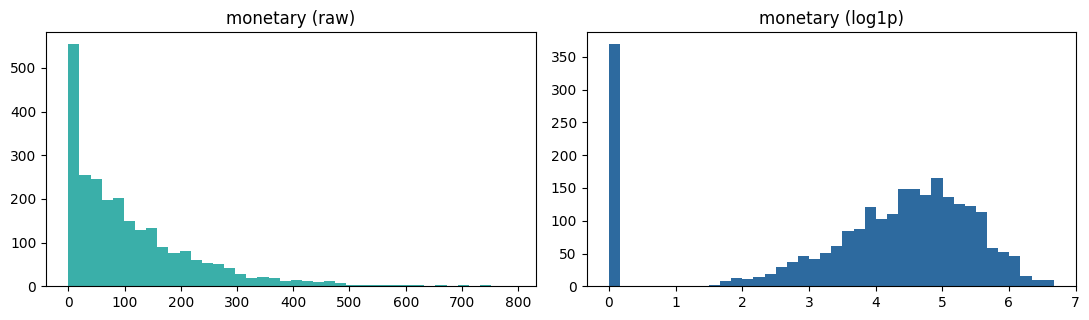

In [10]:
# -----------------------------------------------------------
# 🔹 2A. LOG-TRANSFORM A RIGHT-SKEWED COLUMN
# -----------------------------------------------------------
# EDA showed 'monetary' (total spend) is right-skewed. log1p compresses
# the long tail so big spenders don't dominate the model.
df['monetary_log'] = np.log1p(df['monetary'])   # log1p handles 0 safely
print('skew before:', round(df['monetary'].skew(), 2))
print('skew after :', round(df['monetary_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['monetary'], bins=40, color='#3AAFA9'); ax[0].set_title('monetary (raw)')
ax[1].hist(df['monetary_log'], bins=40, color='#2D6A9F'); ax[1].set_title('monetary (log1p)')
plt.tight_layout(); plt.show()

In [11]:
# 1. skew of avg_order_value (note: NaN for zero-order customers)
df['avg_order_value'] = df['avg_order_value'].fillna(0)

skew before: 2.72
skew after : -1.42


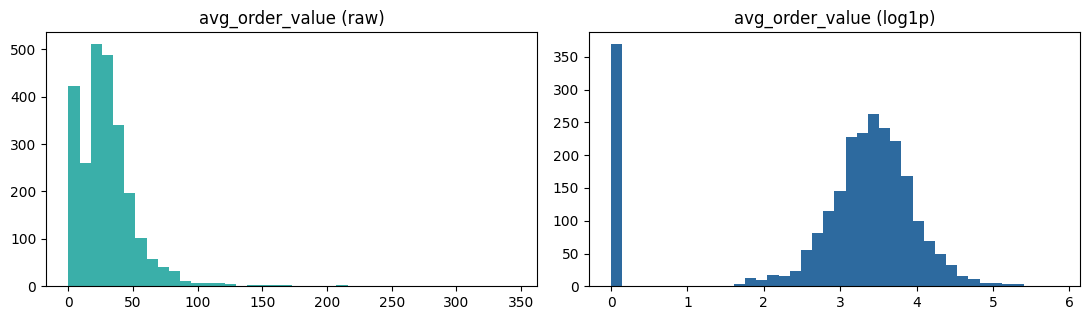

In [12]:
# log-transform

df['avg_order_value_log'] = np.log1p(df['avg_order_value'])
print('skew before:', round(df['avg_order_value'].skew(), 2))
print('skew after :', round(df['avg_order_value_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['avg_order_value'], bins=40, color='#3AAFA9'); ax[0].set_title('avg_order_value (raw)')
ax[1].hist(df['avg_order_value_log'], bins=40, color='#2D6A9F'); ax[1].set_title('avg_order_value (log1p)')
plt.tight_layout(); plt.show()

compared the skewness of avg_order_value before and after log-transformation in the previous step. The skewness changed from 2.72 to -1.42

In [13]:
# -----------------------------------------------------------
# 🔹 3A. BUCKET AGE INTO LIFE-STAGE GROUPS
# -----------------------------------------------------------
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 200],
                         labels=['<25', '25-39', '40-59', '60+'])
print(df['age_group'].value_counts(dropna=False))

age_group
25-39    1025
40-59     872
<25       355
NaN       175
60+        73
Name: count, dtype: int64


In [14]:
#  bucket recency_days  (tip: use bins=[-1, 30, 90, 100000])

df['recency_group'] = pd.cut(df['recency_days'], bins=[-1, 30, 90, 100000],
                             labels=['<30', '30-89', '90+'])
print(df['recency_group'].value_counts(dropna=False))

recency_group
90+      1507
30-89     531
<30       462
Name: count, dtype: int64


The counts for each recency group are:

90+ days: 1507 customers
30-89 days: 531 customers
<30 days: 462 customers

In [15]:
# pd.crosstab(bucket, df['is_churned'], normalize='index')

pd.crosstab(df['recency_group'], df['is_churned'], normalize='index')

is_churned,0,1
recency_group,,
<30,0.932900,0.067100
30-89,0.947269,0.052731
90+,0.763769,0.236231


In [16]:
# -----------------------------------------------------------
# 🔹 4A. RATIOS THAT EXPOSE BEHAVIOUR  (mind divide-by-zero!)
# -----------------------------------------------------------
# tickets per order: a dissatisfaction signal, normalised by activity
df['tickets_per_order'] = df['support_tickets'] / df['frequency'].replace(0, np.nan)
df['tickets_per_order'] = df['tickets_per_order'].fillna(0)   # 0 orders -> 0

# spend per category: concentration of spend
df['spend_per_category'] = df['monetary'] / df['n_categories'].replace(0, np.nan)
df['spend_per_category'] = df['spend_per_category'].fillna(0)
print(df[['support_tickets', 'frequency', 'tickets_per_order',
          'monetary', 'n_categories', 'spend_per_category']].head())

   support_tickets  frequency  tickets_per_order  monetary  n_categories  \
0                2        0.0                0.0      0.00           0.0   
1                1        0.0                0.0      0.00           0.0   
2                1        1.0                1.0     39.17           1.0   
3                1        1.0                1.0      2.74           1.0   
4                0        4.0                0.0    133.80           3.0   

   spend_per_category  
0                0.00  
1                0.00  
2               39.17  
3                2.74  
4               44.60  


In [17]:
# 1. tenure in months, then orders_per_month (guard divide-by-zero)
tenure_months = (SNAPSHOT - df['signup_date']).dt.days / 30

In [18]:
# tenure in months, then orders_per_month (guard divide-by-zero)

df['orders_per_month'] = df['frequency'] / tenure_months.replace(0, np.nan)
df['orders_per_month'] = df['orders_per_month'].fillna(0)
print(df[['customer_id', 'frequency', 'signup_date', 'orders_per_month']].head())

  customer_id  frequency signup_date  orders_per_month
0   CUST00001        0.0  2021-04-19          0.000000
1   CUST00002        0.0  2023-07-31          0.000000
2   CUST00003        1.0  2023-03-07          0.062370
3   CUST00004        1.0  2022-06-18          0.040377
4   CUST00005        4.0  2022-06-11          0.160000


Original Series:
 0    1.0
1    2.0
2    inf
3    4.0
4   -inf
5    NaN
6    7.0
dtype: float64

Series after replacing inf/-inf with NaN and then filling NaN with 0:
 0    1.0
1    2.0
2    0.0
3    4.0
4    0.0
5    0.0
6    7.0
dtype: float64


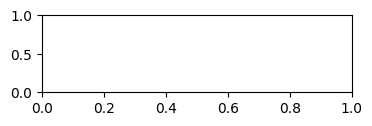

In [20]:
# replace inf/NaN with 0   (hint: .replace([np.inf,-np.inf], np.nan).fillna(0))

# Create a sample Series with inf, -inf, and NaN values for demonstration
sample_series = pd.Series([1, 2, np.inf, 4, -np.inf, np.nan, 7])
print("Original Series:\n", sample_series)

# Apply the suggested method to replace inf/-inf with NaN, then fill all NaN with 0
cleaned_series = sample_series.replace([np.inf, -np.inf], np.nan).fillna(0)

print("\nSeries after replacing inf/-inf with NaN and then filling NaN with 0:\n", cleaned_series)

In [21]:
# top 5 by frequency

top_5_by_frequency = df.sort_values(by='frequency', ascending=False).head(5)
display(top_5_by_frequency[['customer_id', 'frequency']])

,customer_id,frequency
237,CUST00238,19.0
812,CUST00813,18.0
562,CUST00563,17.0
1918,CUST01919,16.0
1199,CUST01200,16.0


In [22]:
# -----------------------------------------------------------
# 🔹 5A. UNLOCK THE DATE COLUMNS
# -----------------------------------------------------------
df['tenure_days'] = (SNAPSHOT - df['signup_date']).dt.days   # how long a customer
df['signup_month'] = df['signup_date'].dt.month
df['signup_dow'] = df['signup_date'].dt.dayofweek            # 0=Mon
df['signup_is_weekend'] = (df['signup_dow'] >= 5).astype(int)
# cyclical encoding so Dec(12) and Jan(1) are 'close', not far apart
df['month_sin'] = np.sin(2 * np.pi * df['signup_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['signup_month'] / 12)
df[['signup_date', 'tenure_days', 'signup_month',
    'signup_dow', 'signup_is_weekend', 'month_sin', 'month_cos']].head()

,signup_date,tenure_days,signup_month,signup_dow,signup_is_weekend,month_sin,month_cos
0,2021-04-19,1168,4,0,0,8.660254e-01,-5.000000e-01
1,2023-07-31,335,7,0,0,-5.000000e-01,-8.660254e-01
2,2023-03-07,481,3,1,0,1.000000e+00,6.123234e-17
3,2022-06-18,743,6,5,1,1.224647e-16,-1.000000e+00
4,2022-06-11,750,6,5,1,1.224647e-16,-1.000000e+00


In [23]:
# days from first_order_date to SNAPSHOT

df['days_since_first_order'] = (SNAPSHOT - df['first_order_date']).dt.days
df['days_since_first_order'] = df['days_since_first_order'].fillna(9999) # For customers with no orders
display(df[['customer_id', 'first_order_date', 'days_since_first_order']].head())

,customer_id,first_order_date,days_since_first_order
0,CUST00001,NaT,9999.0
1,CUST00002,NaT,9999.0
2,CUST00003,2023-05-22,405.0
3,CUST00004,2022-07-02,729.0
4,CUST00005,2022-09-18,651.0


In [24]:
# fill NaT-derived NaN with 0

df['active_span_days'] = df['active_span_days'].fillna(0)
df['avg_days_between_orders'] = df['avg_days_between_orders'].fillna(0)
display(df[['customer_id', 'active_span_days', 'avg_days_between_orders']].head())

,customer_id,active_span_days,avg_days_between_orders
0,CUST00001,0.0,0.0
1,CUST00002,0.0,0.0
2,CUST00003,0.0,0.0
3,CUST00004,0.0,0.0
4,CUST00005,636.0,212.0


In [25]:
# show a few rows

display(df.head())

,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,...,tickets_per_order,spend_per_category,orders_per_month,tenure_days,signup_month,signup_dow,signup_is_weekend,month_sin,month_cos,days_since_first_order
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,...,0.0,0.00,0.000000,1168,4,0,0,8.660254e-01,-5.000000e-01,9999.0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,...,0.0,0.00,0.000000,335,7,0,0,-5.000000e-01,-8.660254e-01,9999.0
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,...,1.0,39.17,0.062370,481,3,1,0,1.000000e+00,6.123234e-17,405.0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,...,1.0,2.74,0.040377,743,6,5,1,1.224647e-16,-1.000000e+00,729.0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,...,0.0,44.60,0.160000,750,6,5,1,1.224647e-16,-1.000000e+00,651.0
